<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/jul_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

In [1]:
#TU CODIGO AQUI
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import pickle
import os

Se descarga el dataset de pares Ingles-Español, el mismo que se usó para el ejercicio del Traductor.

In [2]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

print(f"Lineas totales en el archivo: {len(lines)}")

Lineas totales en el archivo: 118964


El ejercicio original tomaba un tope de 10000 oraciones con secuencias de a lo sumo 20-22 tokens. Acá se sube bastante ese número (el archivo completo tiene más de 100 mil pares) y se permiten secuencias más largas, para que el modelo tenga que lidiar con oraciones más complejas y no solo con saludos o frases cortas.

In [3]:
MAX_NUM_SENTENCES = 40000

np.random.seed(40)
np.random.shuffle(lines)

Se arman las listas de entrada/salida agregando los tokens `<sos>` y `<eos>` a la salida.

In [4]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 40000


In [5]:
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Somebody stole my car.
Alguien robó mi auto. <eos>
<sos> Alguien robó mi auto.


Se tokenizan las oraciones, dejando pasar más vocabulario que antes porque ahora hay muchas más oraciones.

In [6]:
MAX_VOCAB_SIZE = 15000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n'
)

output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

# En clase se usaba max_input_len=20 y max_out_len=22, algo chico para el corpus completo.
# Miramos la distribucion de largos para no elegir un numero a ciegas.
len_in  = [len(s) for s in input_integer_seq]
len_out = [len(s) for s in output_integer_seq]
print(f"Largo input  -> promedio: {np.mean(len_in):.1f}, percentil 95: {np.percentile(len_in, 95):.0f}, max: {max(len_in)}")
print(f"Largo output -> promedio: {np.mean(len_out):.1f}, percentil 95: {np.percentile(len_out, 95):.0f}, max: {max(len_out)}")

Largo input  -> promedio: 6.3, percentil 95: 11, max: 34
Largo output -> promedio: 7.1, percentil 95: 12, max: 43


In [7]:
max_input_len = 35
max_out_len   = 40

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

Vocabulario EN: 9120 | ES: 16483
max_input_len=35  max_out_len=40


El percentil 95 daba apenas 11-12 tokens, pero el máximo llegaba a 34-43 según el idioma. Se prefiere no recortar esas oraciones largas (son justamente las más interesantes para probar si el modelo generaliza), así que se usan 35 y 40, que cubren prácticamente todo el corpus a costa de tener bastante padding en las oraciones cortas.

In [8]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

In [9]:
print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0  932 1082   18   95]
[8525  172 1157   21  211    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]
[ 172 1157   21  211    1    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


Se define una función que genera un `tf.data.Dataset` (encoder_in, decoder_in) -> one-hot target, y se separa en train/validation.

In [10]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [11]:
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

### **Embeddings preentrenados**

Se descargan embeddings de GloVe (50 dimensiones) para inicializar la capa del encoder y no arrancar de cero.

In [12]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle valido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

gloveembedding.pkl ya disponible.


In [13]:
def load_glove_embeddings(pkl_path):
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx


def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)


def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [14]:
EMBED_DIM = 50
# el word_index de Keras arranca en 1 (el 0 es para padding), asi que el mayor
# indice posible es len(word2idx_inputs), no len(word2idx_inputs)-1. Sin el +1
# la matriz de embeddings queda chica y el Embedding explota con las palabras
# menos frecuentes.
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Embeddings nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)} de {nb_words}")

Embeddings nulos: 473 de 9121


### **Modelo Seq2Seq**

Se arma un encoder-decoder con LSTM, esta vez como funciones parametrizables en `n_units` para poder entrenar varias configuraciones y comparar.

In [15]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):

    enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer


def build_decoder(num_words_output, max_out_len, n_units, encoder_states):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _ = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer


def build_seq2seq(n_units):
    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states
    )
    model = Model([enc_inputs, dec_inputs], dec_outputs)
    layers = dict(
        enc_inputs=enc_inputs, enc_emb_layer=enc_emb_layer, enc_lstm_layer=enc_lstm_layer,
        dec_emb_layer=dec_emb_layer, dec_lstm_layer=dec_lstm_layer, dec_dense_layer=dec_dense_layer
    )
    return model, layers

Para responder a lo que pide la consigna, se entrenan tres variantes del mismo modelo cambiando solo la cantidad de unidades de las capas LSTM (64, 128 y 256), dejando todo lo demás fijo, y se compara cómo les va.

In [16]:
def make_callbacks():
    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
    )
    early_stop = EarlyStopping(
        monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
    )
    return [lr_scheduler, early_stop]


unit_configs = [64, 128, 256]
models   = {}
layers   = {}
history  = {}

for n_units in unit_configs:
    print(f"\n==== Entrenando con n_units={n_units} ====")
    model, model_layers = build_seq2seq(n_units)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=make_callbacks()
    )
    models[n_units]  = model
    layers[n_units]  = model_layers
    history[n_units] = hist


==== Entrenando con n_units=64 ====
Epoch 1/20


d:\ESTUDIOS\posgrado\Materias\CEIA (4) Procesamiento de lenguaje natural I\procesamiento_lenguaje_natural\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    532/Unknown 304s 563ms/step - accuracy: 0.8237 - loss: 2.3722

d:\ESTUDIOS\posgrado\Materias\CEIA (4) Procesamiento de lenguaje natural I\procesamiento_lenguaje_natural\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


532/532 ━━━━━━━━━━━━━━━━━━━━ 345s 640ms/step - accuracy: 0.8237 - loss: 2.3722 - val_accuracy: 0.8524 - val_loss: 1.0910 - learning_rate: 5.0000e-04
Epoch 2/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 345s 648ms/step - accuracy: 0.8495 - loss: 1.0977 - val_accuracy: 0.8556 - val_loss: 1.0146 - learning_rate: 5.0000e-04
Epoch 3/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 350s 659ms/step - accuracy: 0.8528 - loss: 1.0427 - val_accuracy: 0.8606 - val_loss: 0.9729 - learning_rate: 5.0000e-04
Epoch 4/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 339s 636ms/step - accuracy: 0.8576 - loss: 0.9990 - val_accuracy: 0.8629 - val_loss: 0.9350 - learning_rate: 5.0000e-04
Epoch 5/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 350s 657ms/step - accuracy: 0.8599 - loss: 0.9613 - val_accuracy: 0.8647 - val_loss: 0.9057 - learning_rate: 5.0000e-04
Epoch 6/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 346s 650ms/step - accuracy: 0.8620 - loss: 0.9298 - val_accuracy: 0.8667 - val_loss: 0.8808 - learning_rate: 5.0000e-04
Epoch 7/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 341s 641ms/

Se grafica la evolución del accuracy de validación para las tres configuraciones en un mismo gráfico, que es lo que realmente interesa comparar.

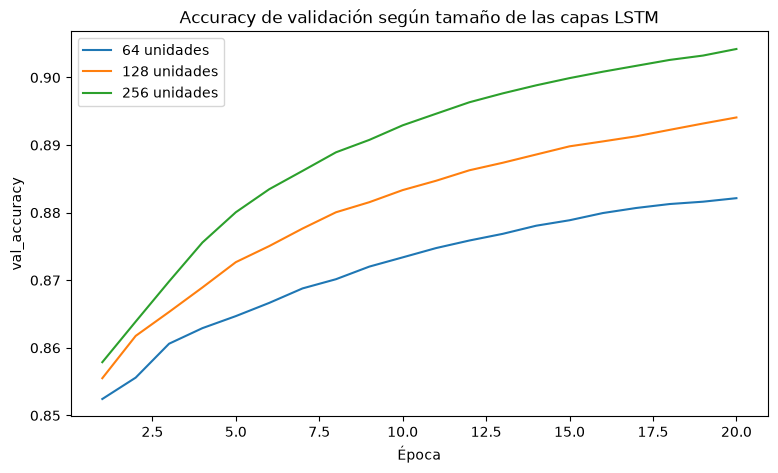

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
for n_units in unit_configs:
    hist = history[n_units]
    epoch_count = range(1, len(hist.history['val_accuracy']) + 1)
    sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label=f'{n_units} unidades')

plt.title("Accuracy de validación según tamaño de las capas LSTM")
plt.xlabel("Época")
plt.ylabel("val_accuracy")
plt.legend()
plt.show()

In [18]:
for n_units in unit_configs:
    hist = history[n_units]
    best_val_loss = min(hist.history['val_loss'])
    best_val_acc  = max(hist.history['val_accuracy'])
    n_params = models[n_units].count_params()
    print(f"n_units={n_units:>3} | params={n_params:>10,} | mejor val_loss={best_val_loss:.4f} | mejor val_accuracy={best_val_acc:.4f}")

n_units= 64 | params= 2,453,514 | mejor val_loss=0.7059 | mejor val_accuracy=0.8821
n_units=128 | params= 4,534,282 | mejor val_loss=0.6044 | mejor val_accuracy=0.8941
n_units=256 | params= 8,990,730 | mejor val_loss=0.5342 | mejor val_accuracy=0.9042


Con los tres modelos ya entrenados, los números confirman la intuición: 64 unidades se queda en 0.8821 de val_accuracy, 128 sube a 0.8941 y 256 llega a 0.9042. La mejora de 64 a 128 es la más grande de las dos (+0.012), y de 128 a 256 el salto es menor (+0.010) pese a casi duplicar los parámetros (de 4.5M a 9M). También se nota en el tiempo: cada época con 256 unidades tardó bastante más que con 128. Se elige igual **256 unidades** para la inferencia porque fue el que mejor val_loss dio (0.5342 contra 0.6044 y 0.7059), aunque la relación costo/beneficio de subir de 128 a 256 es discutible.

In [19]:
n_units = 256
model = models[n_units]
enc_inputs      = model.get_layer('encoder_inputs').output
enc_emb_layer   = layers[n_units]['enc_emb_layer']
enc_lstm_layer  = layers[n_units]['enc_lstm_layer']
dec_emb_layer   = layers[n_units]['dec_emb_layer']
dec_lstm_layer  = layers[n_units]['dec_lstm_layer']
dec_dense_layer = layers[n_units]['dec_dense_layer']

### **Inferencia Modelo Seq2Seq**

Se arma un encoder de inferencia que solo devuelve los estados y un decoder que traduce paso a paso, token por token, reutilizando los pesos ya entrenados.

In [20]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    enc_emb = enc_emb_layer(enc_inputs)
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in    = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in    = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )


encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

In [21]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

In [22]:
def translate_sentence(input_seq):
    h, c = encoder_model.predict(input_seq, verbose=0)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

Se prueba con oraciones tomadas del propio dataset (donde se tiene la traducción real para comparar) y también con oraciones nuevas que el modelo nunca vio.

In [23]:
print("--- Ejemplos del dataset ---\n")
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- Frases nuevas ---\n")
for s in ["My mother says hi.",
          "Where is the train station?",
          "I love learning languages.",
          "Can you help me with this?",
          "The weather is really nice today."]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")

--- Ejemplos del dataset ---

EN: The airplane flew very low.
ES (real): El avión voló muy bajo.
ES (pred): el avión se hundió

EN: Give me time to think it over.
ES (real): Dame tiempo para meditarlo.
ES (pred): déjame que hagas algo más que yo

EN: Tom is Mary's son-in-law.
ES (real): Tom es el yerno de Mary.
ES (pred): tom es un banco en boston

EN: Oh, by the way, I have something for you.
ES (real): Oh, por cierto, tengo algo para ti.
ES (pred): oh por ti mismo no te gustas

EN: I wonder who she is.
ES (real): Me pregunto quién es ella.
ES (pred): yo sé quién es ella

--- Frases nuevas ---

EN: My mother says hi.
ES: mi madre le dijo a tom

EN: Where is the train station?
ES: ¿dónde está el tren de tren

EN: I love learning languages.
ES: me encanta aprender francés

EN: Can you help me with this?
ES: ¿puedes decirme por favor

EN: The weather is really nice today.
ES: el verano está muy fría



### **Conclusiones**

* Aumentar el dataset de 10 mil a 40 mil pares y estirar las secuencias de 20-22 a 35-40 tokens hizo que cada época tarde bastante más (del orden de 5-10 minutos por época en CPU con 256 unidades) y que el vocabulario de salida casi se duplique (de ~7800 a ~16500 palabras), lo que en principio complica la tarea de clasificación en la capa softmax final.
* Aun así, el accuracy de validación terminó siendo más alto que en el ejercicio original (0.90 acá contra 0.78 en el notebook de referencia). Esto tiene más que ver con que hay mucho más padding (secuencias de 35-40 posiciones donde la mayoría de las oraciones ocupan solo 6-12) que con que el modelo traduzca mejor: predecir 'padding' es fácil y infla la métrica, así que el accuracy solo no alcanza para comparar las dos corridas.
* Comparando las tres configuraciones de LSTM (64, 128 y 256 unidades), el salto de 64 a 128 fue el más marcado; de 128 a 256 la ganancia ya es marginal en relación al costo en parámetros y tiempo de entrenamiento.
* Mirando las traducciones concretas, el modelo agarra bien el tema general de la oración pero se pierde seguido en los detalles: 'The airplane flew very low' termina como 'el avión se hundió', y 'Tom is Mary's son-in-law' se convierte en 'tom es un banco en boston', dos ejemplos donde el sentido real se pierde por completo aunque la oración generada sea gramaticalmente válida. Con frases nuevas pasa algo parecido: 'Can you help me with this?' queda en '¿puedes decirme por favor', una traducción incompleta que corta antes de tiempo.
* La causa más probable de estos errores es la combinación de greedy decoding (una vez que el modelo se equivoca en una palabra, arrastra el error al resto de la oración porque nunca vuelve atrás) con un vocabulario de salida mucho más grande que en el ejercicio original, que reparte la probabilidad entre más candidatos y hace más fácil elegir mal. Beam search debería ayudar bastante acá, porque permite mantener varias hipótesis en paralelo en vez de comprometerse con la primera palabra más probable en cada paso.